# Point statistics

The `ps` (point statistics) module provides metrics to compare the mean spatial distribution of transcripts in relation to the centroid and the segmented outline of the cell. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. The computed values can either be returned as a dictionary or stored in place in the `spatialdata` object.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa
import segtraq
from pathlib import Path

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

In [3]:
# # Load spatial transcriptomics dataset and initalize SegTraQ object
# sdata = sd.read_zarr("../../data/xenium.zarr")

# # only looking at a subset for visualization purposes
# bb_xmin = 800
# bb_ymin = 1150
# bb_w = 200
# bb_h = 300
# bb_xmax = bb_xmin + bb_w
# bb_ymax = bb_ymin + bb_h
# sdata = sdata.query.bounding_box(
#     axes=["x", "y"],
#     min_coordinate=[bb_xmin, bb_ymin],
#     max_coordinate=[bb_xmax, bb_ymax],
#     target_coordinate_system="global",
# )

# #initialize SegTraQ object
# st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")

In [4]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")
sdata = sd.read_zarr(data_path / "proseg_output_v3/sdata_proseg_crop.zarr")

st = segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:131: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/bl/baseline.py:528: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = geom.area.values


## Centroid mean coordinate difference

To assess the spatial distribution of a gene's transcripts within a cell, we can look at the "center of mass" of the transcripts and compare it to the centroid of the cell. 
The metric can either be computed per gene (as demonstrated below), or for all genes simultaneously (by using the `genes` argument). We compute the euclidean distance between the mean coordinate per transcript $\mu_{x,y}$ with the cell centroid coordinate $cc_{x,y}$ normalised by the cell area $|C|$. The normalisation by cell area is necessary because the computed euclidean distance scales with the cell area.

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{|C|}
$$

In [11]:
# for one single gene
st.ps.centroid_mean_coord_diff(["ERBB2"], restrict_to_within_boundary=True)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/ps/point_statistics.py:223: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: OGC:CRS84
Right CRS: None

  within = poly.covers(pt)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/ps/point_statistics.py:239: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  {centroid_key[0]: gdf.centroid.x, centroid_key[1]: gdf.centroid.y},


,cell,distance_ERBB2
0,70089,0.308538
1,70131,0.676596
2,70136,0.345586
3,70156,0.543042
4,70159,0.294329
...,...,...
275,76393,0.332983
276,76404,0.230351
277,76407,0.189698
278,76425,0.397705


In [12]:
sdata["table"].obs["distance_ERBB2"].mean()

np.float64(0.25705172171737994)

This result is also stored in `spatialdata` object and accesible in the observations of the `anndata` component.

In [13]:
sdata["table"].obs[sdata["table"].obs["distance_ERBB2"].notna()].head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,cell_area,distance_MMP9,distance_ERBB2
70089,70089,77202,2178.318604,2681.480225,0.361413,4,46.00,288.0,1.0,cell_boundaries,113.0,NaN,0.308538
70131,70131,78086,2127.435303,2723.807373,0.381740,5,102.00,442.0,1.0,cell_boundaries,188.0,NaN,0.676596
70136,70136,78088,2126.911621,2740.182373,0.407609,2,40.25,256.0,1.0,cell_boundaries,92.0,NaN,0.345586
70156,70156,77948,2128.573975,2781.690674,0.446429,2,49.00,304.0,1.0,cell_boundaries,73.0,NaN,0.543042
70159,70159,77951,2135.409180,2787.758301,0.401718,2,32.75,240.0,1.0,cell_boundaries,52.0,NaN,0.294329


We can visualise these results in space for the gene ERBB2

WARNING  Found 1253 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

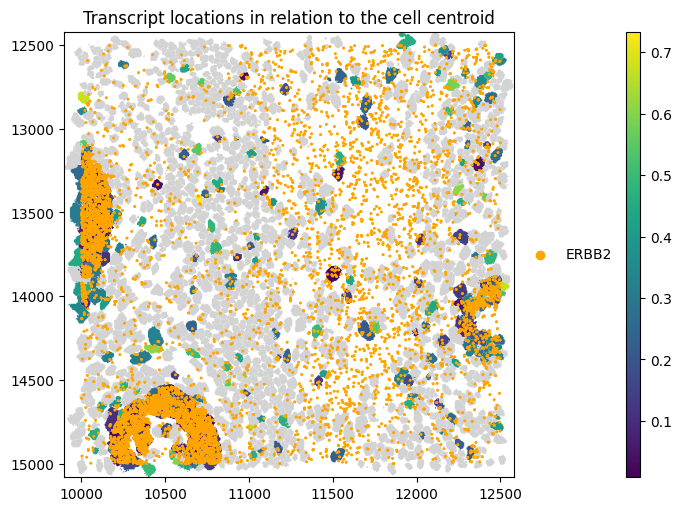

In [14]:
sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    title="Transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We notice that there are some cells with a lot of cells at the boundary and some others that are more balanced.

## Distance to membrane

Another way to look at the spatial distribution of transcripts is the distance of a gene's transcripts to the membrane. In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

The metric is defined as the mean distance to the cell membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by the cell area $|C|$.
Again, this can be applied either to specific genes or all genes simultaneously.

$$
d_{membrane} = \frac{\mu(d(m,t))}{|C|}
$$

In [17]:
st.ps.distance_to_membrane("ERBB2", restrict_to_within_boundary=True)

,assignment,distance_to_outline_ERBB2,distance_to_outline_norm_ERBB2,distance_to_outline_inverse_ERBB2
0,70089.0,2.623181,0.246768,0.617427
1,70131.0,0.674602,0.049200,1.217520
2,70136.0,2.149917,0.224144,0.682007
3,70156.0,0.196045,0.022945,2.258505
4,70159.0,0.934082,0.129534,1.034683
...,...,...,...,...
275,76393.0,0.905392,0.150899,1.050949
276,76404.0,1.602447,0.150083,0.789965
277,76407.0,3.163777,0.263648,0.562208
278,76425.0,2.484129,0.205588,0.634473


In [18]:
sdata["table"].obs["distance_to_outline_norm_ERBB2"].mean()

np.float64(0.1478839948808021)

Also this result is also stored in spatialdata object and accesible in the observations of the anndata component.

In [ ]:
sdata["table"].obs[
    sdata["table"].obs["distance_to_outline_norm_ERBB2"].notna()
    | sdata["table"].obs["distance_to_outline_inverse_ERBB2"].notna()
]

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,cell_area,distance_3_genes,distance_CD3E,distance_ERBB2,distance_VIM,distance_NOS3,distance_MMP9,distance_to_outline_ERBB2,distance_to_outline_norm_ERBB2,distance_to_outline_inverse_ERBB2
70089,70089,77202,2178.318604,2681.480225,0.361413,4,46.00,288.0,1.0,cell_boundaries,113.0,0.275640,0.125768,0.308538,NaN,NaN,NaN,2.623181,0.246768,0.617427
70129,70129,77958,2114.024658,2803.340820,0.378102,0,241.75,668.0,1.0,cell_boundaries,359.0,NaN,NaN,0.821969,NaN,NaN,NaN,-16.032782,-0.846178,0.249744
70131,70131,78086,2127.435303,2723.807373,0.381740,5,102.00,442.0,1.0,cell_boundaries,188.0,0.124621,NaN,0.707352,NaN,NaN,NaN,0.219991,0.016045,2.132045
70136,70136,78088,2126.911621,2740.182373,0.407609,2,40.25,256.0,1.0,cell_boundaries,92.0,0.345586,NaN,0.345586,NaN,NaN,NaN,2.149917,0.224144,0.682007
70144,70144,77203,2178.535400,2721.405273,0.339706,8,63.75,318.0,1.0,cell_boundaries,105.0,0.234059,NaN,0.664139,NaN,NaN,NaN,-0.900222,-0.087853,1.053962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76403,76403,95300,2594.336670,3165.147705,0.359642,4,73.25,360.0,1.0,cell_boundaries,155.0,0.085993,NaN,0.977630,NaN,NaN,NaN,-4.537526,-0.364463,0.469451
76404,76404,95286,2604.679688,3162.649658,0.407939,9,74.00,378.0,1.0,cell_boundaries,114.0,0.230351,NaN,0.230351,NaN,NaN,NaN,1.602447,0.150083,0.789965
76407,76407,94084,2618.889160,3172.875244,0.447279,9,73.50,384.0,1.0,cell_boundaries,144.0,0.189698,NaN,0.272800,NaN,NaN,NaN,1.325099,0.110425,0.868712
76425,76425,94072,2651.201172,3139.671875,0.423722,1,78.25,358.0,1.0,cell_boundaries,146.0,0.397705,NaN,0.397705,NaN,NaN,NaN,2.484129,0.205588,0.634473


We can also plot this metric in space.

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

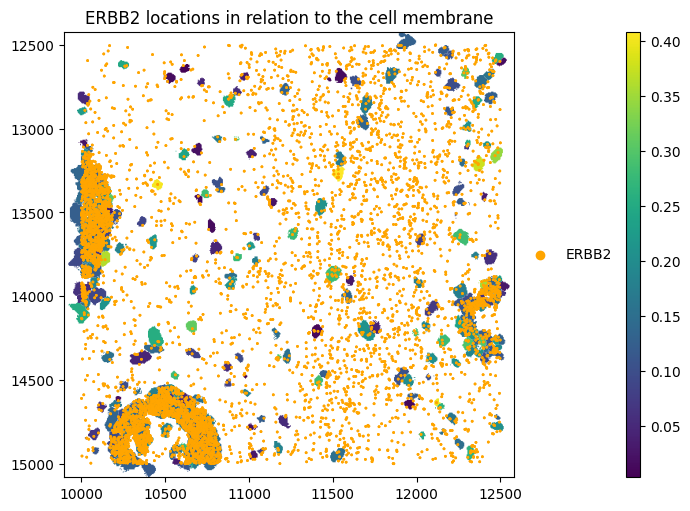

In [19]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_outline_norm_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_outline_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

We note that the two metrics are complementary to each other. However, there are situations with irregularly shaped cells where the distance to the centroid might be very small although the transcripts are clearly on the boarder of the cell.

## Periphery Enrichment Score

We can also compute the periphery enrichment score. For each cell, we divide the cell into an outer halo (erosion by 30% of the radius) and an inner part. We then aggregate all genes, and count how many transcripts we see on the inner vs. outer part. Both of these then are divided by their area to get the density. The rationale is, that a higher density of transcripts in the outer region could be due to spillover. Finally, we take the ratio of the border density vs. the inner density. If this is 1, our densities are equal. A value below one indicates a higher concentration of transcripts in the nucleus, whereas a value above one indicates higher transcript density in the outer region of the cell. This can be computed for individual genes as well as all genes (with the `genes` argument).

To avoid division by 0, pseudocounts are added if there is at least 1 transcript assigned to the cell. If both the border and the center expression are 0, we set the density ratio to NaN.

In [20]:
# the score we are interested in here is the "density_ratio"
periphery_df = st.ps.periphery_enrichment_score("ERBB2")
periphery_df.head()

/g/huber/users/lazic/src/SegTraQ/src/segtraq/rc/utils.py:177: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = cells_gdf.geometry.area
/g/huber/users/lazic/src/SegTraQ/src/segtraq/ps/point_statistics.py:556: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pd.DataFrame({"cell_id": center_gdf.index, f"center_area_{feature}": center_gdf.geometry.area.values}),
/g/huber/users/lazic/src/SegTraQ/src/segtraq/ps/point_statistics.py:559: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pd.DataFrame({"cell_id": border_gdf.index, f"border_area_{feature}": border_gdf.geometry.area.values}),


,cell_id,center_expr_ERBB2,border_expr_ERBB2,center_area_ERBB2,border_area_ERBB2,border_density_ERBB2,center_density_ERBB2,density_ratio_ERBB2
0,70066,0,0,8.165073,20.834927,0.047996,0.122473,NaN
1,70067,0,0,28.592073,52.407927,0.019081,0.034975,NaN
2,70069,0,0,11.430426,31.569574,0.031676,0.087486,NaN
3,70070,0,0,23.889871,45.110129,0.022168,0.041859,NaN
4,70071,0,0,14.846204,25.153796,0.039755,0.067357,NaN


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_uv/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.s

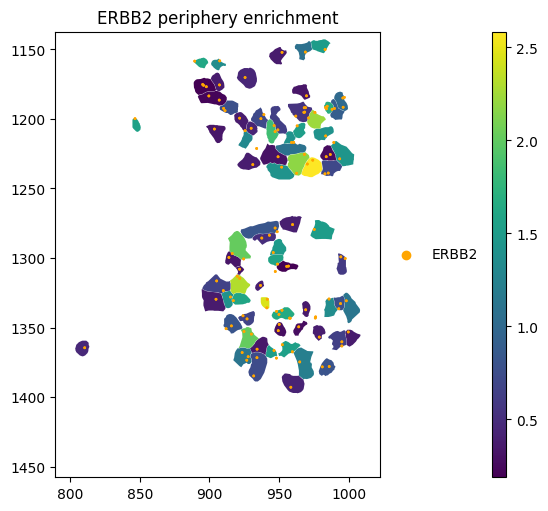

In [12]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["density_ratio_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="density_ratio_ERBB2",
    cmap="viridis",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 periphery enrichment",
    coordinate_systems="global",
    figsize=(10, 5),
)

## Comparing the three metrics

Let's look at all three metrics right next to one another. We will only consider the metrics computed on all transcripts here, and not look at individual genes.

In [ ]:
_ = st.ps.centroid_mean_coord_diff()
_ = st.ps.distance_to_membrane()
_ = st.ps.periphery_enrichment_score()

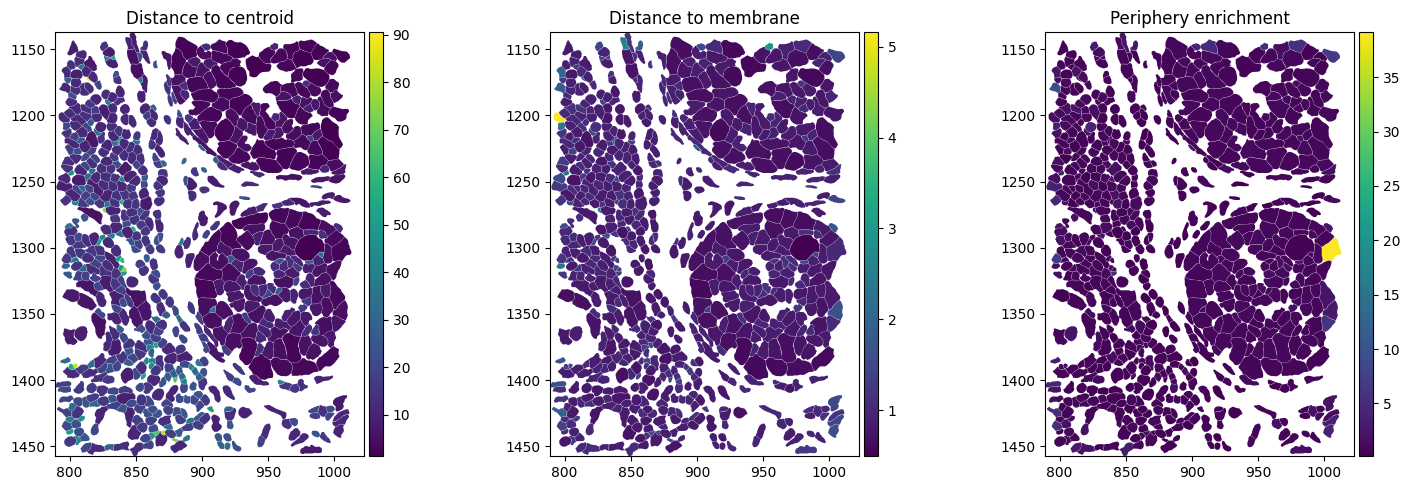

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="distance_all_genes",
).pl.show(
    title="Distance to centroid",
    coordinate_systems="global",
    ax=ax[0],
)

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_outline_inverse_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_outline_inverse_all_genes",
).pl.show(
    title="Distance to membrane",
    coordinate_systems="global",
    ax=ax[1],
)

# periphery enrichment
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["density_ratio_all_genes"].notna()]
sdata_plot.pl.render_shapes(
    element="cell_boundaries",
    color="density_ratio_all_genes",
).pl.show(
    title="Periphery enrichment",
    coordinate_systems="global",
    ax=ax[2],
)

plt.tight_layout()